<a href="https://colab.research.google.com/github/kspohn903/Google_Drive_Repository/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output data will be saved to: /content/drive/MyDrive/Netflix_EDA/Data
Output graphics will be saved to: /content/drive/MyDrive/Netflix_EDA/Graphics
Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows

Dataset loaded successfully.
Initial DataFrame saved to /content/drive/MyDrive/Netflix_EDA/Data/netflix_titles_initial.csv

--- Head of the dataset ---
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0      

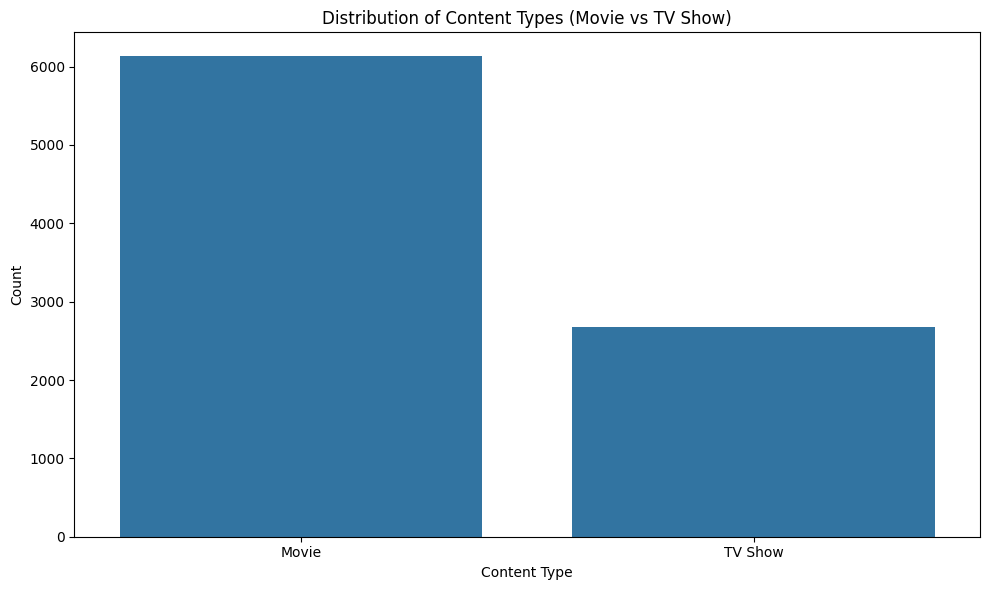

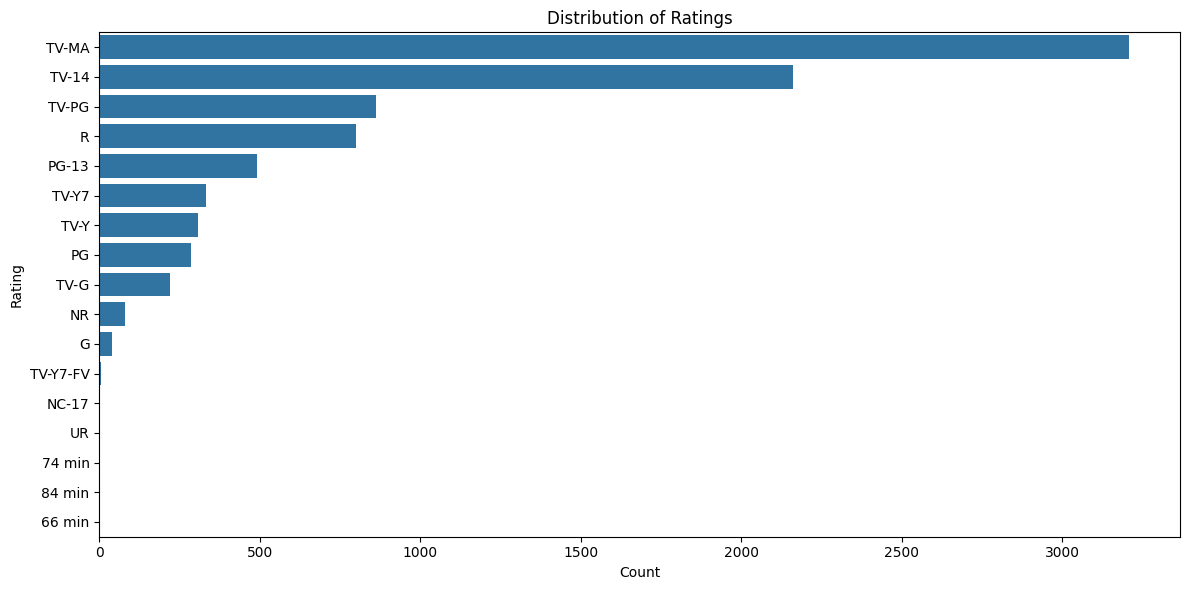

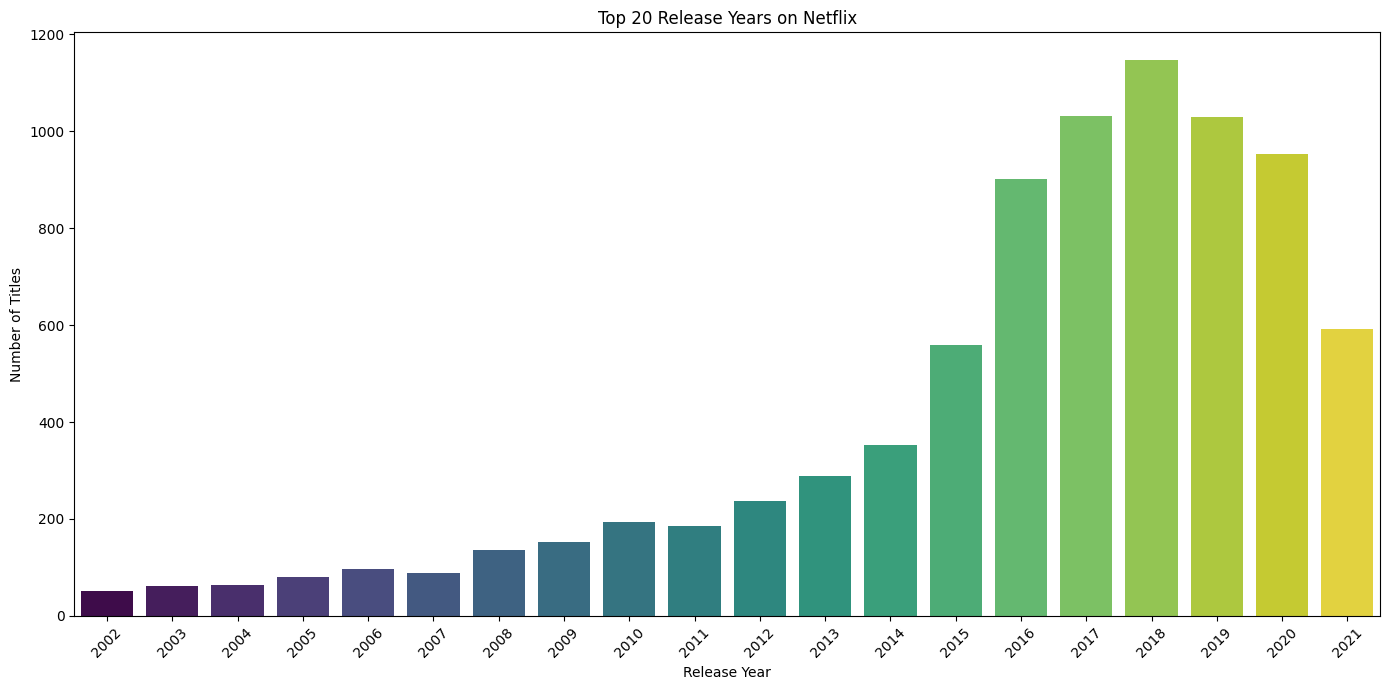


--- EDA Complete ---
You can further explore specific columns, relationships, and trends based on these initial insights.


In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the base directory for saving outputs
output_base_dir = '/content/drive/MyDrive/Netflix_EDA'
output_data_dir = os.path.join(output_base_dir, 'Data')
output_graphics_dir = os.path.join(output_base_dir, 'Graphics')

# Create directories if they don't exist
os.makedirs(output_data_dir, exist_ok=True)
os.makedirs(output_graphics_dir, exist_ok=True)

print(f"Output data will be saved to: {output_data_dir}")
print(f"Output graphics will be saved to: {output_graphics_dir}")

# 1. Download the dataset using kagglehub
print("Downloading dataset...")
path = kagglehub.dataset_download("shivamb/netflix-shows")
print(f"Dataset downloaded to: {path}")

# Assuming the CSV file is directly in the downloaded path or a subdirectory
# Let's list files in the downloaded path to find the correct CSV file
import os
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if not csv_files:
    print("No CSV files found in the downloaded directory.")
elif len(csv_files) > 1:
    print(f"Multiple CSV files found: {csv_files}. Loading the first one: {csv_files[0]}")
    df = pd.read_csv(os.path.join(path, csv_files[0]))
else:
    df = pd.read_csv(os.path.join(path, csv_files[0]))

print("\nDataset loaded successfully.")
df.to_csv(os.path.join(output_data_dir, 'netflix_titles_initial.csv'), index=False)
print(f"Initial DataFrame saved to {os.path.join(output_data_dir, 'netflix_titles_initial.csv')}")

# 2. Basic EDA
print("\n--- Head of the dataset ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Unique Values in Key Categorical Columns ---")
for col in ['type', 'rating', 'release_year']:
    if col in df.columns:
        print(f"\nUnique values in '{col}':")
        print(df[col].value_counts())

# 3. Visualizations (Examples)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type')
plt.title('Distribution of Content Types (Movie vs TV Show)')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'content_type_distribution.png'))
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'rating_distribution.png'))
plt.show()

# Distribution of release years (Top 20)
plt.figure(figsize=(14, 7))
release_year_counts = df['release_year'].value_counts().sort_index(ascending=False).head(20)
sns.barplot(x=release_year_counts.index, y=release_year_counts.values, palette='viridis', hue=release_year_counts.index, legend=False)
plt.title('Top 20 Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'top_20_release_years.png'))
plt.show()

print("\n--- EDA Complete ---")
print("You can further explore specific columns, relationships, and trends based on these initial insights.")


### Top 10 Countries by Content Count

DataFrame with filled country values saved to /content/drive/MyDrive/Netflix_EDA/Data/netflix_titles_country_filled.csv
Country counts saved to /content/drive/MyDrive/Netflix_EDA/Data/country_counts.csv
Top 10 countries saved to /content/drive/MyDrive/Netflix_EDA/Data/top_10_countries.csv


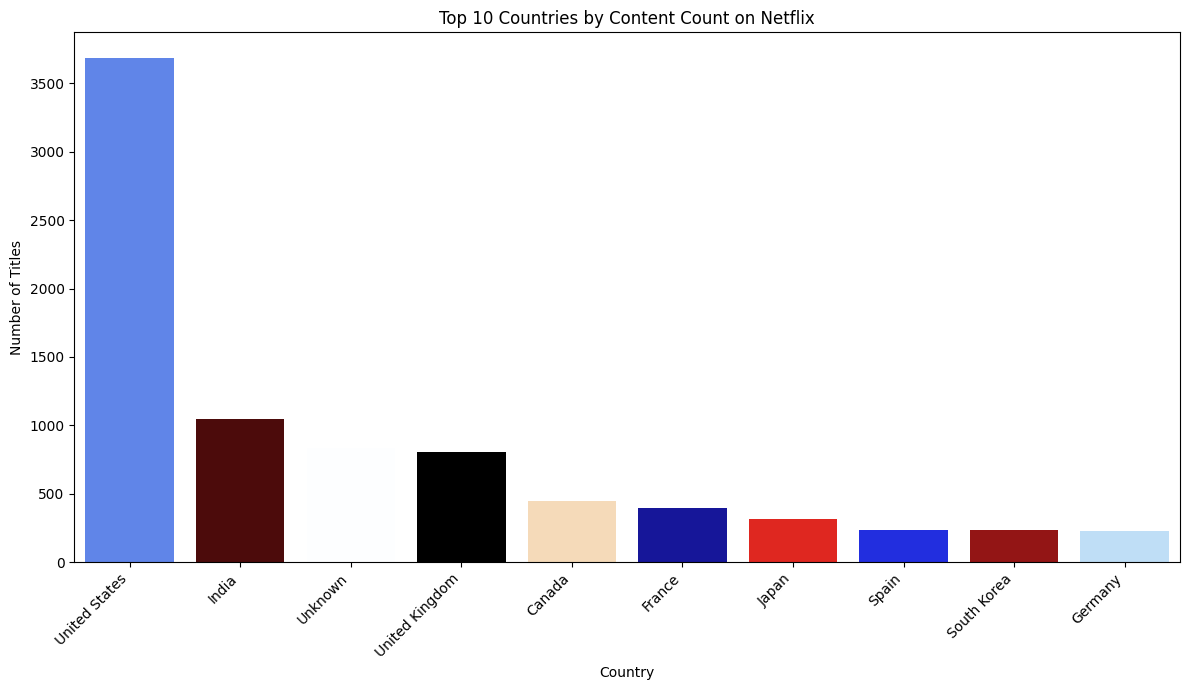

In [ ]:
# It's important to handle cases where a title might be listed under multiple countries.
# For this analysis, we'll consider the first country listed if there are multiple.
# First, fill missing 'country' values with 'Unknown' for better analysis.
df['country'] = df['country'].fillna('Unknown')
df.to_csv(os.path.join(output_data_dir, 'netflix_titles_country_filled.csv'), index=False)
print(f"DataFrame with filled country values saved to {os.path.join(output_data_dir, 'netflix_titles_country_filled.csv')}")

# Split countries if there are multiple and count each individual country
country_counts = df['country'].str.split(', ', expand=True).stack().value_counts()
country_counts.to_csv(os.path.join(output_data_dir, 'country_counts.csv'))
print(f"Country counts saved to {os.path.join(output_data_dir, 'country_counts.csv')}")

# Get the top 10 countries
top_10_countries = country_counts.head(10)
top_10_countries.to_csv(os.path.join(output_data_dir, 'top_10_countries.csv'))
print(f"Top 10 countries saved to {os.path.join(output_data_dir, 'top_10_countries.csv')}")

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='flag', hue=top_10_countries.index, legend=False)
plt.title('Top 10 Countries by Content Count on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'top_10_countries.png'))
plt.show()


### Content Distribution by Rating and Type

Rating type counts saved to /content/drive/MyDrive/Netflix_EDA/Data/rating_type_counts.csv
Content counts by Rating and Type:


type,TV Show,Movie
rating,,
UR,0,3
TV-Y7-FV,1,5
TV-Y7,195,139
TV-Y,176,131
TV-PG,323,540
TV-MA,1145,2062
TV-G,94,126
TV-14,733,1427
R,2,797


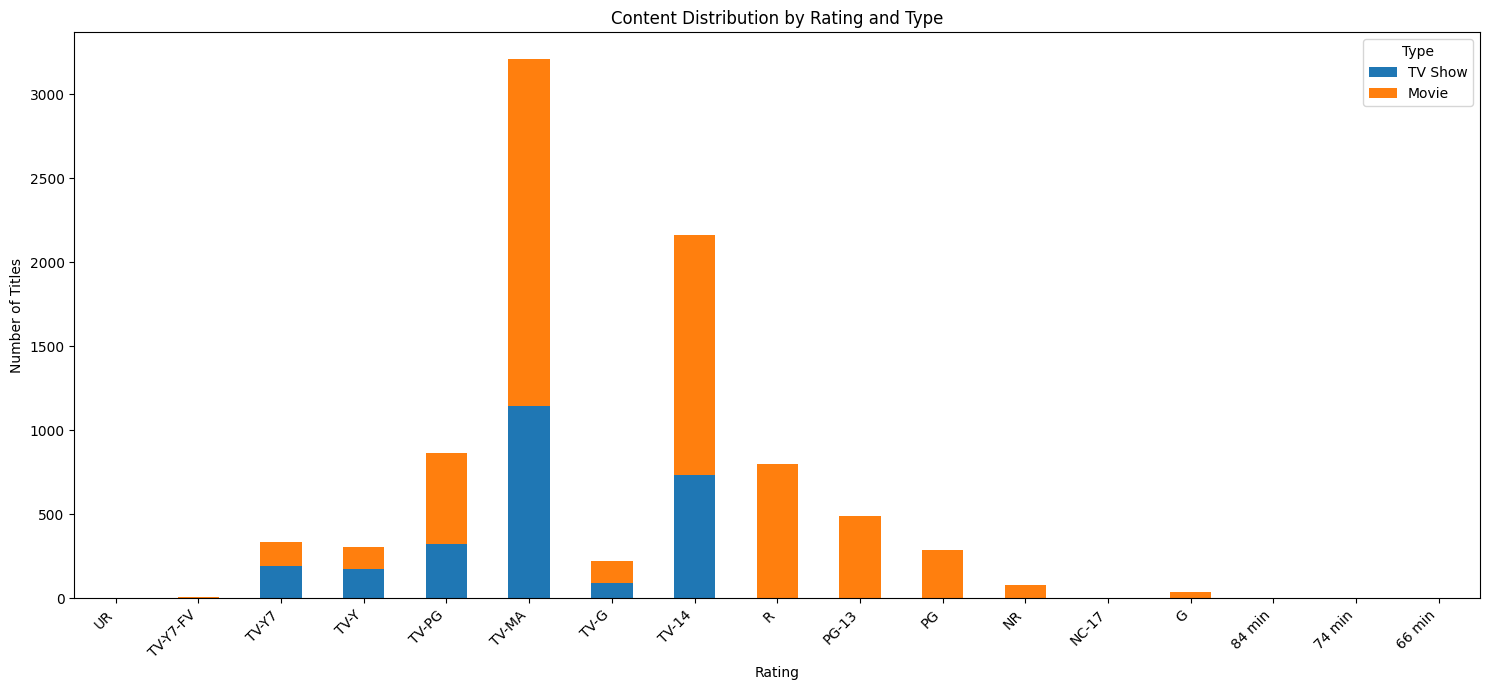

In [ ]:
# Group by 'rating' and 'type' and count occurrences
rating_type_counts = df.groupby(['rating', 'type']).size().unstack(fill_value=0)

# Order by 'rating' (index) descending, then by 'type' (column names) descending
rating_type_counts = rating_type_counts.sort_index(ascending=False).sort_index(axis=1, ascending=False)
rating_type_counts.to_csv(os.path.join(output_data_dir, 'rating_type_counts.csv'))
print(f"Rating type counts saved to {os.path.join(output_data_dir, 'rating_type_counts.csv')}")

print("Content counts by Rating and Type:")
display(rating_type_counts)

# Optional: Visualize the distribution
fig = rating_type_counts.plot(kind='bar', figsize=(15, 7), stacked=True) # Changed to fig for saving
plt.title('Content Distribution by Rating and Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
fig.figure.savefig(os.path.join(output_graphics_dir, 'content_by_rating_and_type.png'))
plt.show()


### Content Distribution by Rating for Top 5 Countries

Top 5 countries DataFrame saved to /content/drive/MyDrive/Netflix_EDA/Data/df_top_5_countries.csv


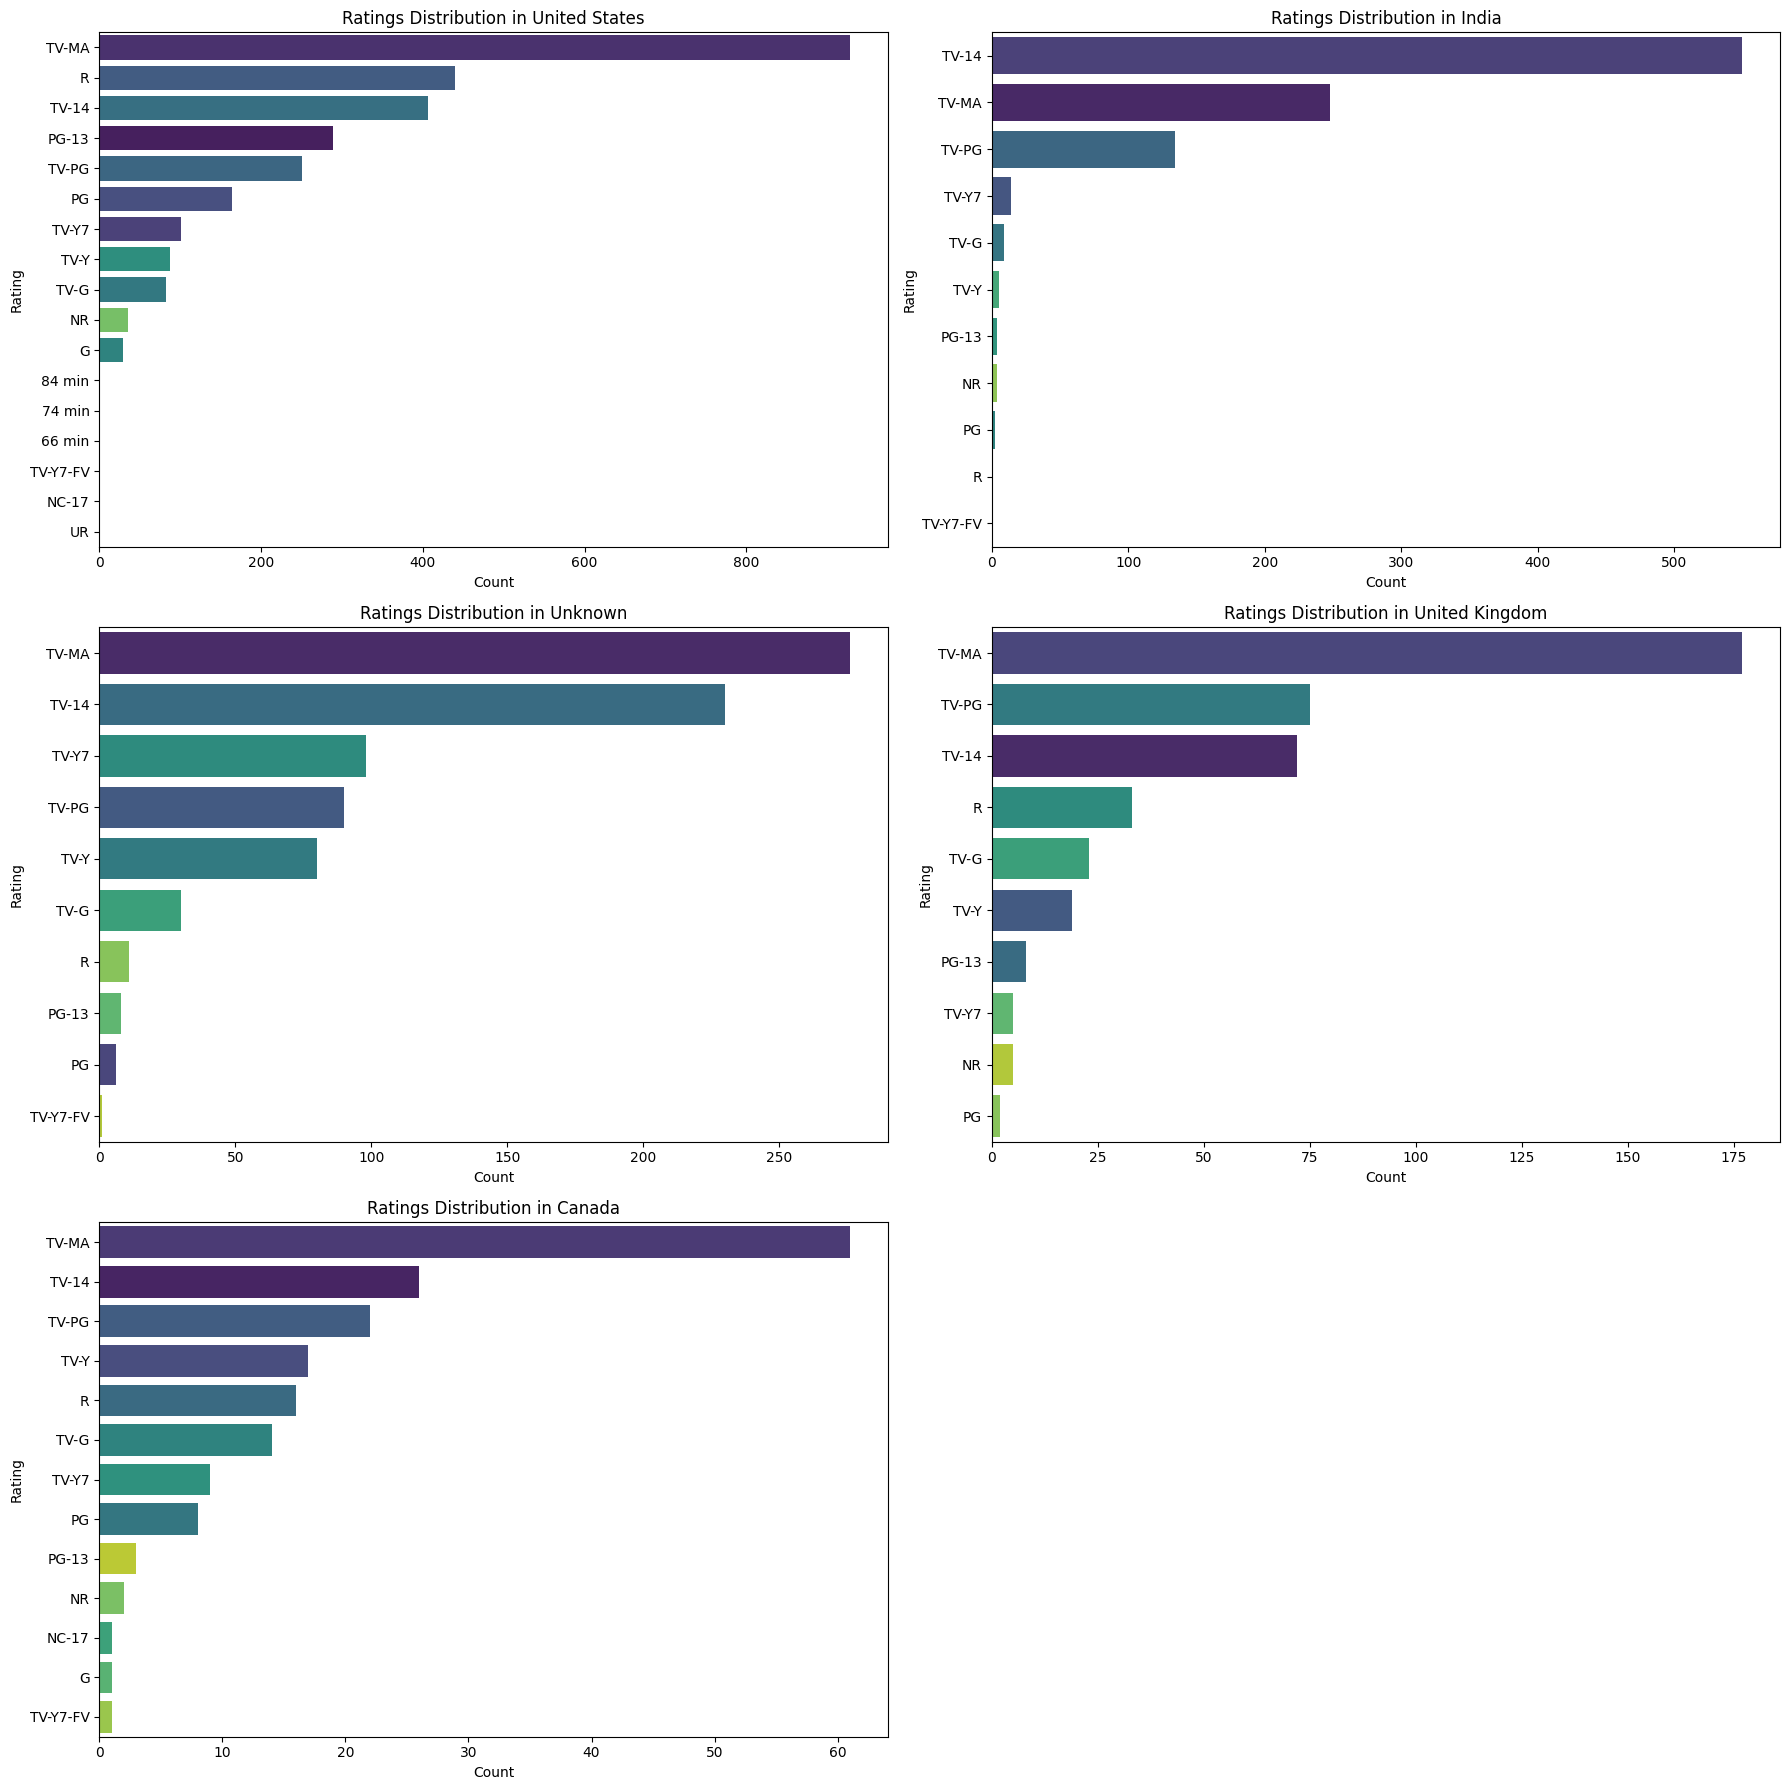

In [ ]:
# Get the top 5 countries
top_5_countries = top_10_countries.index.tolist()[:5]

# Filter the DataFrame for content from these top 5 countries
df_top_countries = df[df['country'].isin(top_5_countries)]
df_top_countries.to_csv(os.path.join(output_data_dir, 'df_top_5_countries.csv'), index=False)
print(f"Top 5 countries DataFrame saved to {os.path.join(output_data_dir, 'df_top_5_countries.csv')}")

# Create subplots for each of the top 5 countries
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, country in enumerate(top_5_countries):
    subset_df = df_top_countries[df_top_countries['country'] == country]
    sns.countplot(data=subset_df, y='rating', order=subset_df['rating'].value_counts().index, ax=axes[i], palette='viridis', hue='rating', legend=False)
    axes[i].set_title(f'Ratings Distribution in {country}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('Rating')

# Hide any unused subplots (if top_5_countries is less than 6)
for j in range(len(top_5_countries), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
fig.savefig(os.path.join(output_graphics_dir, 'ratings_distribution_top_5_countries.png'))
plt.show()


### Distribution of Content Genres ('listed_in')

Genre counts saved to /content/drive/MyDrive/Netflix_EDA/Data/genre_counts.csv
Top 10 Most Popular Genres:


,count
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641
Romantic Movies,616


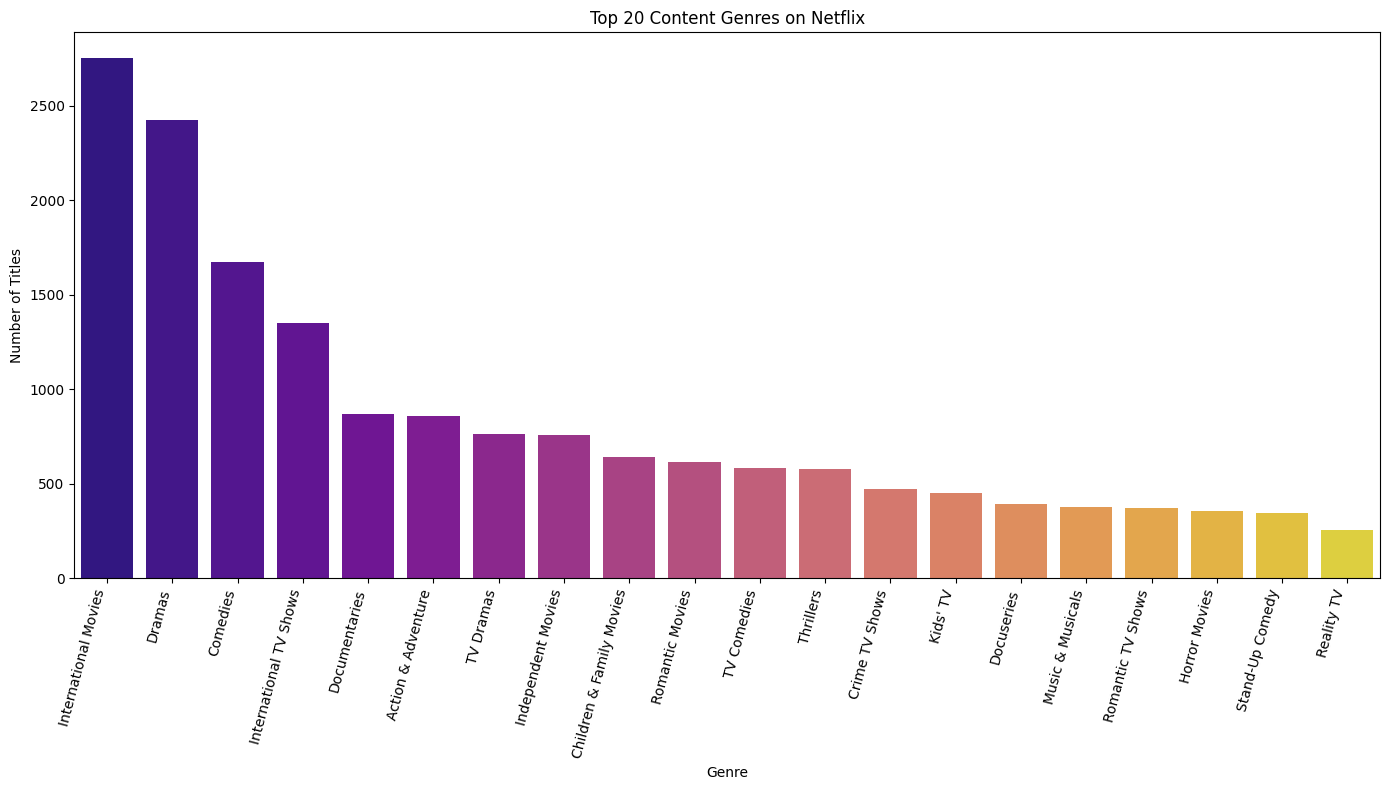

In [ ]:
# Split the 'listed_in' column to get individual genres
genres = df['listed_in'].str.split(', ', expand=True).stack()

# Count the occurrences of each genre
genre_counts = genres.value_counts()
genre_counts.to_csv(os.path.join(output_data_dir, 'genre_counts.csv'))
print(f"Genre counts saved to {os.path.join(output_data_dir, 'genre_counts.csv')}")

# Display the top 10 most popular genres
print("Top 10 Most Popular Genres:")
display(genre_counts.head(10))

# Plot the top 20 genres
plt.figure(figsize=(14, 8))
sns.barplot(x=genre_counts.head(20).index, y=genre_counts.head(20).values, palette='plasma', hue=genre_counts.head(20).index, legend=False)
plt.title('Top 20 Content Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=75, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'top_20_genres.png'))
plt.show()


### Top Directors for 'International Movies' Genre

International movies DataFrame saved to /content/drive/MyDrive/Netflix_EDA/Data/international_movies_df.csv
Director counts for international movies saved to /content/drive/MyDrive/Netflix_EDA/Data/director_counts.csv
Top 10 Directors for 'International Movies':


,count
Cathy Garcia-Molina,13
Youssef Chahine,10
Yılmaz Erdoğan,9
Kunle Afolayan,8
Johnnie To,8
Umesh Mehra,8
Hanung Bramantyo,8
Hakan Algül,8
David Dhawan,8
Anurag Kashyap,8


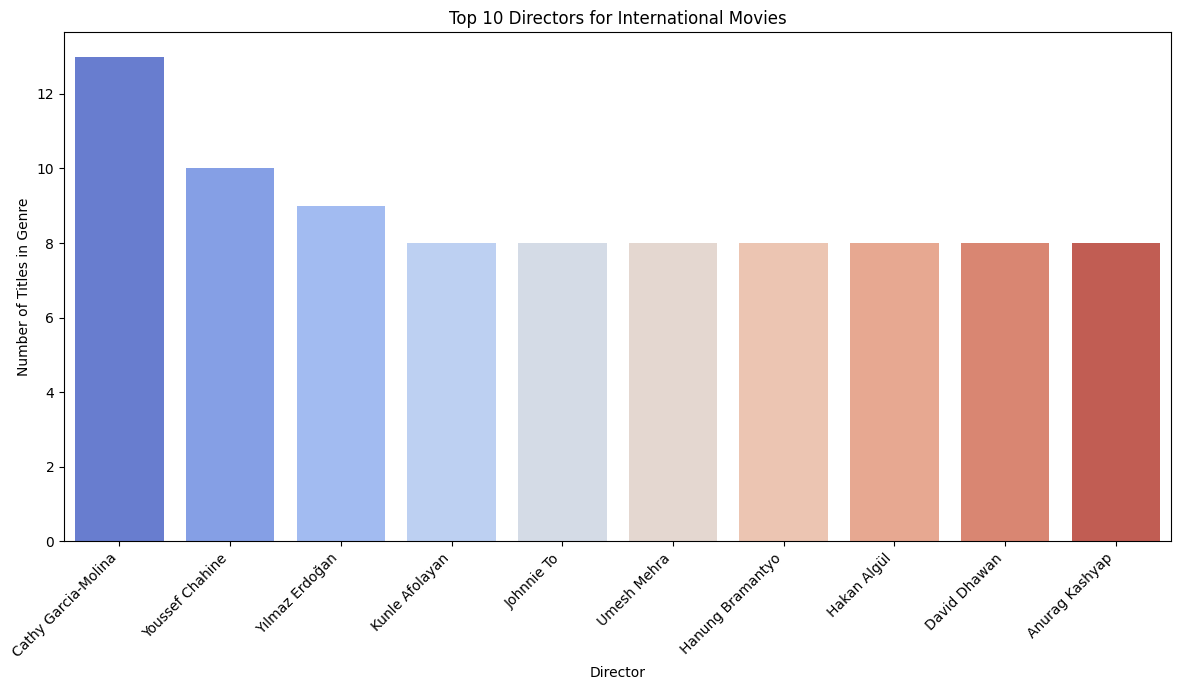

In [ ]:
# Filter the DataFrame for content categorized as 'International Movies'
international_movies_df = df[df['listed_in'].str.contains('International Movies', na=False)].copy()
international_movies_df.to_csv(os.path.join(output_data_dir, 'international_movies_df.csv'), index=False)
print(f"International movies DataFrame saved to {os.path.join(output_data_dir, 'international_movies_df.csv')}")

# Fill missing director values with 'Unknown' for analysis purposes
international_movies_df['director'] = international_movies_df['director'].fillna('Unknown')

# Handle cases where multiple directors are listed (split and stack)
directors = international_movies_df['director'].str.split(', ', expand=True).stack()

# Count the occurrences of each director
director_counts = directors.value_counts()

# Exclude 'Unknown' from the top directors list if it's there
director_counts = director_counts[director_counts.index != 'Unknown']
director_counts.to_csv(os.path.join(output_data_dir, 'director_counts.csv'))
print(f"Director counts for international movies saved to {os.path.join(output_data_dir, 'director_counts.csv')}")

# Display the top 10 directors for International Movies
print("Top 10 Directors for 'International Movies':")
display(director_counts.head(10))

# Visualize the top 10 directors
plt.figure(figsize=(12, 7))
sns.barplot(x=director_counts.head(10).index, y=director_counts.head(10).values, palette='coolwarm', hue=director_counts.head(10).index, legend=False)
plt.title('Top 10 Directors for International Movies')
plt.xlabel('Director')
plt.ylabel('Number of Titles in Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'top_10_directors_international_movies.png'))
plt.show()


### Program Duration by Type

In [ ]:
# Clean the 'duration' column

# Separate movies and TV shows
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

# For movies, extract minutes and convert to numeric
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '', regex=False).astype(float)
movies_df.to_csv(os.path.join(output_data_dir, 'movies_df.csv'), index=False)
print(f"Movies DataFrame saved to {os.path.join(output_data_dir, 'movies_df.csv')}")

# For TV shows, extract seasons and convert to numeric
tv_shows_df['duration_seasons'] = tv_shows_df['duration'].str.replace(' Season[s]?', '', regex=True).astype(float)
tv_shows_df.to_csv(os.path.join(output_data_dir, 'tv_shows_df.csv'), index=False)
print(f"TV Shows DataFrame saved to {os.path.join(output_data_dir, 'tv_shows_df.csv')}")

print("Movie durations (first 5):")
display(movies_df[['title', 'duration', 'duration_minutes']].head())

print("\nTV Show durations (first 5):")
display(tv_shows_df[['title', 'duration', 'duration_seasons']].head())


Movies DataFrame saved to /content/drive/MyDrive/Netflix_EDA/Data/movies_df.csv
TV Shows DataFrame saved to /content/drive/MyDrive/Netflix_EDA/Data/tv_shows_df.csv
Movie durations (first 5):


,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0



TV Show durations (first 5):


,title,duration,duration_seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0


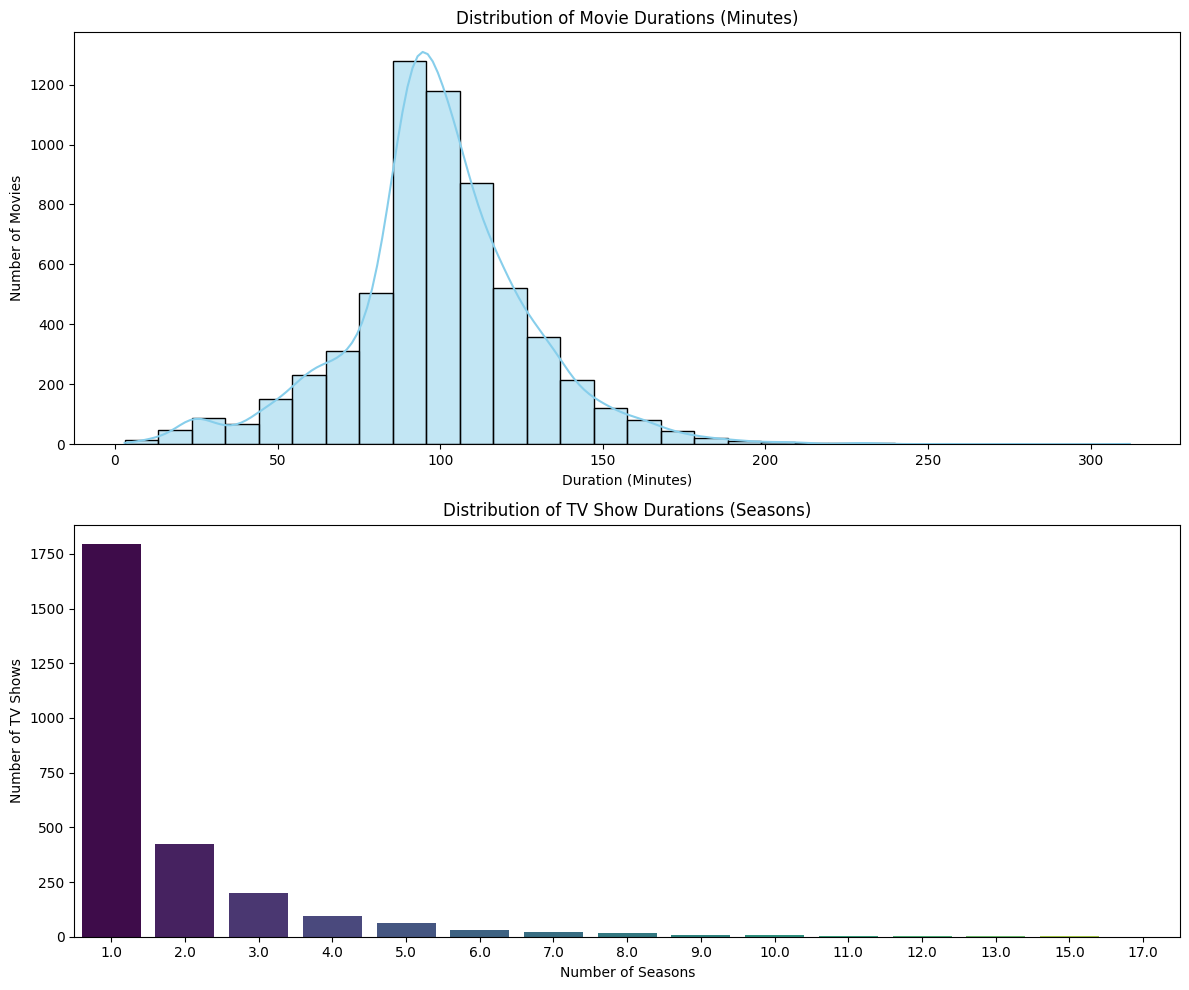

In [ ]:
# Plotting program duration for each type in subplots

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Subplot 1: Movie Duration (in minutes)
sns.histplot(data=movies_df, x='duration_minutes', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Movie Durations (Minutes)')
axes[0].set_xlabel('Duration (Minutes)')
axes[0].set_ylabel('Number of Movies')

# Subplot 2: TV Show Duration (in seasons)
sns.countplot(data=tv_shows_df, x='duration_seasons', ax=axes[1], palette='viridis', hue=tv_shows_df['duration_seasons'], legend=False)
axes[1].set_title('Distribution of TV Show Durations (Seasons)')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Number of TV Shows')

plt.tight_layout()
fig.savefig(os.path.join(output_graphics_dir, 'duration_distribution_movies_tv_shows.png'))
plt.show()


### Setup Google Drive and Output Directories

In [ ]:
# The Google Drive setup has been moved to the initial data loading cell (_YBNKNhOOTqy).
# This cell is now redundant and can be removed.


### Correlation Heatmap

Movie correlation data saved to /content/drive/MyDrive/Netflix_EDA/Data/correlation_movies.csv


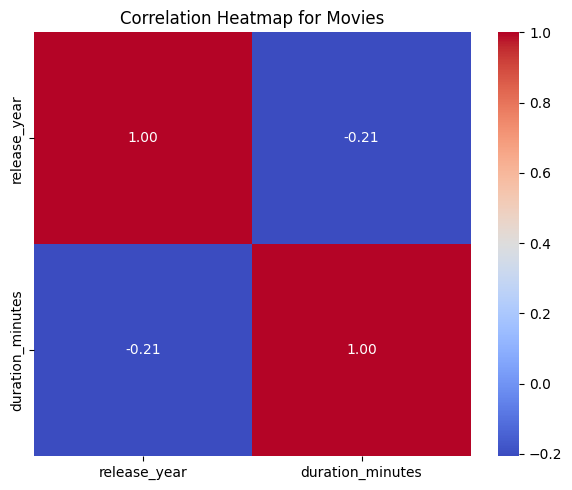

Correlation for Movies:



,release_year,duration_minutes
release_year,1.000000,-0.206285
duration_minutes,-0.206285,1.000000


TV Show correlation data saved to /content/drive/MyDrive/Netflix_EDA/Data/correlation_tv_shows.csv


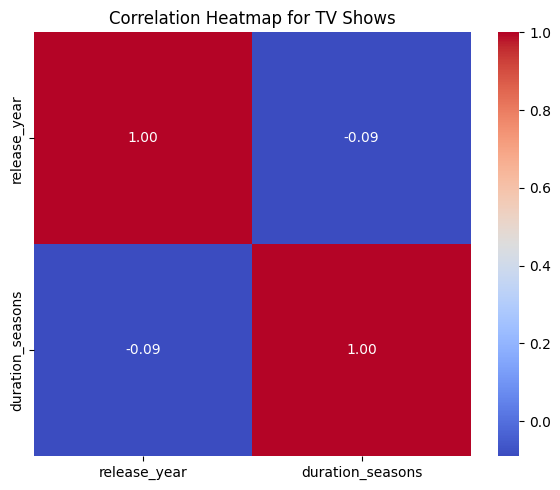

Correlation for TV Shows:



,release_year,duration_seasons
release_year,1.000000,-0.090194
duration_seasons,-0.090194,1.000000


In [ ]:
# For a meaningful correlation heatmap, let's look at numerical columns.
# The primary numerical column is 'release_year'.
# We also have derived numerical durations for movies and TV shows.

# --- Correlation for Movies ---
# Select numerical columns for movies_df
movies_numeric_df = movies_df[['release_year', 'duration_minutes']]
correlation_movies = movies_numeric_df.corr()
correlation_movies.to_csv(os.path.join(output_data_dir, 'correlation_movies.csv'))
print(f"Movie correlation data saved to {os.path.join(output_data_dir, 'correlation_movies.csv')}")

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_movies, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for Movies')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'correlation_heatmap_movies.png'))
plt.show()

print("Correlation for Movies:\n")
display(correlation_movies)

# --- Correlation for TV Shows ---
# Select numerical columns for tv_shows_df
tv_shows_numeric_df = tv_shows_df[['release_year', 'duration_seasons']]
correlation_tv_shows = tv_shows_numeric_df.corr()
correlation_tv_shows.to_csv(os.path.join(output_data_dir, 'correlation_tv_shows.csv'))
print(f"TV Show correlation data saved to {os.path.join(output_data_dir, 'correlation_tv_shows.csv')}")

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_tv_shows, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for TV Shows')
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'correlation_heatmap_tv_shows.png'))
plt.show()

print("Correlation for TV Shows:\n")
display(correlation_tv_shows)


### ANOVA Models

In [ ]:
from scipy.stats import f_oneway

# Helper function to clean ratings (remove duration-like strings)
def clean_rating(rating_series):
    # Filter out ratings that look like durations
    cleaned_series = rating_series[~rating_series.astype(str).str.contains(' min| Season', na=False)]
    return cleaned_series

# --- ANOVA for Movie Duration by Rating ---
# Clean ratings in movies_df for ANOVA
movies_df['cleaned_rating'] = clean_rating(movies_df['rating'])
movies_df_valid_ratings = movies_df.dropna(subset=['duration_minutes', 'cleaned_rating'])

anova_results_movies = []
for rating_category in movies_df_valid_ratings['cleaned_rating'].unique():
    group_data = movies_df_valid_ratings[movies_df_valid_ratings['cleaned_rating'] == rating_category]['duration_minutes']
    anova_results_movies.append(group_data)

# Perform ANOVA if there are at least two groups with data
if len(anova_results_movies) >= 2:
    f_statistic_movies, p_value_movies = f_oneway(*anova_results_movies)
    print(f"ANOVA for Movie Duration by Rating: F-statistic={f_statistic_movies:.2f}, p-value={p_value_movies:.3f}")
    movie_anova_df = pd.DataFrame({
        'Metric': ['Movie Duration vs Rating'],
        'F-statistic': [f_statistic_movies],
        'p-value': [p_value_movies]
    })
    movie_anova_filepath = os.path.join(output_data_dir, 'anova_movie_duration_by_rating.csv')
    movie_anova_df.to_csv(movie_anova_filepath, index=False)
    print(f"ANOVA results for movie duration saved to {movie_anova_filepath}")
else:
    print("Not enough valid rating groups for ANOVA on movie duration.")

# --- ANOVA for TV Show Seasons by Rating ---
# Clean ratings in tv_shows_df for ANOVA
tv_shows_df['cleaned_rating'] = clean_rating(tv_shows_df['rating'])
tv_shows_df_valid_ratings = tv_shows_df.dropna(subset=['duration_seasons', 'cleaned_rating'])

anova_results_tv_shows = []
for rating_category in tv_shows_df_valid_ratings['cleaned_rating'].unique():
    group_data = tv_shows_df_valid_ratings[tv_shows_df_valid_ratings['cleaned_rating'] == rating_category]['duration_seasons']
    anova_results_tv_shows.append(group_data)

# Perform ANOVA if there are at least two groups with data
if len(anova_results_tv_shows) >= 2:
    f_statistic_tv_shows, p_value_tv_shows = f_oneway(*anova_results_tv_shows)
    print(f"ANOVA for TV Show Seasons by Rating: F-statistic={f_statistic_tv_shows:.2f}, p-value={p_value_tv_shows:.3f}")
    tv_show_anova_df = pd.DataFrame({
        'Metric': ['TV Show Seasons vs Rating'],
        'F-statistic': [f_statistic_tv_shows],
        'p-value': [p_value_tv_shows]
    })
    tv_show_anova_filepath = os.path.join(output_data_dir, 'anova_tv_show_seasons_by_rating.csv')
    tv_show_anova_df.to_csv(tv_show_anova_filepath, index=False)
    print(f"ANOVA results for TV show seasons saved to {tv_show_anova_filepath}")
else:
    print("Not enough valid rating groups for ANOVA on TV show seasons.")

ANOVA for Movie Duration by Rating: F-statistic=98.11, p-value=0.000
ANOVA results for movie duration saved to /content/drive/MyDrive/Netflix_EDA/Data/anova_movie_duration_by_rating.csv
ANOVA for TV Show Seasons by Rating: F-statistic=2.47, p-value=0.012
ANOVA results for TV show seasons saved to /content/drive/MyDrive/Netflix_EDA/Data/anova_tv_show_seasons_by_rating.csv


### Saving Key EDA Graphics to Google Drive

In [ ]:
# This cell previously re-generated and saved plots.
# All plots are now saved directly when they are first generated in their respective cells.
# Therefore, this cell is now redundant and can be removed.
print("All key EDA graphics have been saved to Google Drive in their respective generation cells.")


All key EDA graphics have been saved to Google Drive in their respective generation cells.


### Regression Analysis: Predict Movie Duration by Release Year

In [ ]:
import statsmodels.formula.api as smf

# Prepare data for regression
# We already have 'movies_df' with 'duration_minutes' and 'release_year'

# Define the regression formula
# We want to predict 'duration_minutes' using 'release_year'
formula = 'duration_minutes ~ release_year'

# Fit the linear regression model
model = smf.ols(formula=formula, data=movies_df).fit()

# Print the model summary
print("\n--- Regression Model Summary (Movie Duration vs. Release Year) ---")
print(model.summary())


--- Regression Model Summary (Movie Duration vs. Release Year) ---
                            OLS Regression Results                            
Dep. Variable:       duration_minutes   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     272.3
Date:                Sun, 24 May 2026   Prob (F-statistic):           7.02e-60
Time:                        14:24:31   Log-Likelihood:                -29045.
No. Observations:                6128   AIC:                         5.809e+04
Df Residuals:                    6126   BIC:                         5.811e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

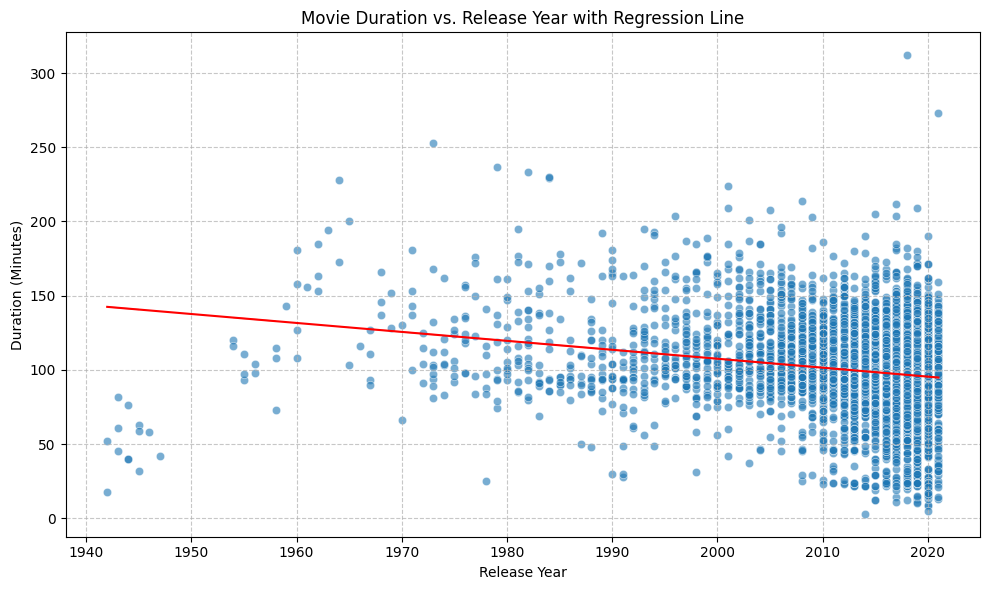

Regression analysis plot saved to Google Drive.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the regression results
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_df, x='release_year', y='duration_minutes', alpha=0.6)

# Add the regression line
# This uses the predictions from the fitted model
sns.lineplot(x=movies_df['release_year'], y=model.predict(movies_df['release_year']), color='red')

plt.title('Movie Duration vs. Release Year with Regression Line')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_graphics_dir, 'movie_duration_regression_by_year.png'))
plt.show()

print("Regression analysis plot saved to Google Drive.")